# App Femi Notebook: Penguins EDA

Author: Oluwafemi Salawu  
Date: 2026-05  

## Purpose

This notebook performs exploratory data analysis on the Seaborn Penguins dataset.

## Phase 4: Technical Modification

For my technical modification, I added new engineered fields to the dataset:

- `body_mass_kg`
- `flipper_body_ratio`
- `size_category`

I also added code to save chart images into the `artifacts/` folder so they can be used in the README or submitted as proof of work.

## Phase 5: Apply the Skills to a New Problem

I applied the EDA skills to a new problem: helping a wildlife researcher compare penguin body size patterns by species and island.

The goal is to answer questions such as:

- Which species has the highest average body mass?
- Which island has the largest penguins on average?
- How do flipper length and body mass relate to species differences?

In [1]:
# Imports and Setup

import logging
from pathlib import Path

from datafun_toolkit.logger import get_logger, log_header
from IPython.display import display
from matplotlib.axes import Axes
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

LOG: logging.Logger = get_logger("EDA", level="DEBUG")

NUMERIC_COLS = [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

GROUP_COL = "species"

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

log_header(LOG, "Exploratory Data Analysis (EDA) - Penguins")

2026-05-24 14:45:37 | INFO | EDA | === RUN START ===
2026-05-24 14:45:37 | INFO | EDA | project=Exploratory Data Analysis (EDA) - Penguins
2026-05-24 14:45:37 | INFO | EDA | repo_dir=datafun-04-notebooks
2026-05-24 14:45:37 | INFO | EDA | python=3.14.2
2026-05-24 14:45:37 | INFO | EDA | os=Windows 11
2026-05-24 14:45:37 | INFO | EDA | shell=powershell
2026-05-24 14:45:37 | INFO | EDA | cwd=notebooks
2026-05-24 14:45:37 | INFO | EDA | github_actions=False


In [2]:
# Load the Data


def load_data() -> pd.DataFrame:
    """Load the Penguins dataset from Seaborn."""
    LOG.info("Loading penguins dataset from seaborn")
    df = sns.load_dataset("penguins")
    LOG.info("Data loaded: %s rows, %s columns", df.shape[0], df.shape[1])
    return df


df = load_data()
display(df.head())

2026-05-24 14:45:37 | INFO | EDA | Loading penguins dataset from seaborn
2026-05-24 14:45:37 | INFO | EDA | Data loaded: 344 rows, 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Inspect Basic Structure


def inspect_basic(df: pd.DataFrame) -> None:
    """Inspect the basic structure of the dataset."""
    LOG.info("Inspecting first rows of data")
    display(df.head())

    LOG.info("Column names")
    print(list(df.columns))

    LOG.info("DataFrame info")
    df.info()

    LOG.info("Dataset shape: %s rows, %s columns", df.shape[0], df.shape[1])


inspect_basic(df)

2026-05-24 14:45:37 | INFO | EDA | Inspecting first rows of data


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


2026-05-24 14:45:37 | INFO | EDA | Column names
2026-05-24 14:45:37 | INFO | EDA | DataFrame info
2026-05-24 14:45:37 | INFO | EDA | Dataset shape: 344 rows, 7 columns


['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
# Build Data Dictionary


def build_data_dictionary(df: pd.DataFrame) -> pd.DataFrame:
    """Build a starter data dictionary."""
    LOG.info("Building starter data dictionary")

    data_dictionary = pd.DataFrame(
        {
            "column": df.columns,
            "dtype": [str(t) for t in df.dtypes],
            "missing_count": df.isna().sum().values,
            "missing_pct": (df.isna().mean() * 100).round(2).values,
        }
    )

    return data_dictionary


data_dictionary = build_data_dictionary(df)
display(data_dictionary)

2026-05-24 14:45:37 | INFO | EDA | Building starter data dictionary


,column,dtype,missing_count,missing_pct
0,species,str,0,0.00
1,island,str,0,0.00
2,bill_length_mm,float64,2,0.58
3,bill_depth_mm,float64,2,0.58
4,flipper_length_mm,float64,2,0.58
5,body_mass_g,float64,2,0.58
6,sex,str,11,3.20


In [5]:
# Check Data Quality


def check_quality(df: pd.DataFrame) -> None:
    """Perform basic data quality checks."""
    LOG.info("Checking missing values per column")
    missing_values = df.isna().sum().sort_values(ascending=False)
    display(missing_values)

    dup_count = int(df.duplicated().sum())
    LOG.info("Duplicate rows detected: %s", dup_count)
    print(f"Duplicate rows detected: {dup_count}")

    LOG.info("Basic sanity check for numeric columns")
    display(df[NUMERIC_COLS].describe())


check_quality(df)

2026-05-24 14:45:37 | INFO | EDA | Checking missing values per column


sex                  11
bill_depth_mm         2
bill_length_mm        2
flipper_length_mm     2
body_mass_g           2
island                0
species               0
dtype: int64

2026-05-24 14:45:37 | INFO | EDA | Duplicate rows detected: 0
2026-05-24 14:45:37 | INFO | EDA | Basic sanity check for numeric columns


Duplicate rows detected: 0


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [6]:
# Create a Clean View


def make_clean_view(df: pd.DataFrame) -> pd.DataFrame:
    """Create a cleaned view for EDA.

    The original DataFrame is unchanged.
    Rows with missing key numeric values or missing species are removed.
    """
    LOG.info("Creating cleaned view for EDA")
    df_clean = df.dropna(subset=NUMERIC_COLS + [GROUP_COL]).copy()

    LOG.info(
        "Cleaned view shape: %s rows, %s columns",
        df_clean.shape[0],
        df_clean.shape[1],
    )

    return df_clean


df_clean = make_clean_view(df)
display(df_clean.head())
print(f"Cleaned DataFrame shape: {df_clean.shape}")

2026-05-24 14:45:37 | INFO | EDA | Creating cleaned view for EDA
2026-05-24 14:45:37 | INFO | EDA | Cleaned view shape: 342 rows, 7 columns


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


Cleaned DataFrame shape: (342, 7)


In [7]:
# Descriptive Statistics


def descriptive_stats(df_clean: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Compute descriptive statistics overall and by species."""
    LOG.info("Computing overall descriptive statistics")
    stats_overall = df_clean[NUMERIC_COLS].describe().T

    LOG.info("Computing descriptive statistics by species")
    stats_by_species = df_clean.groupby(GROUP_COL)[NUMERIC_COLS].agg(
        ["count", "mean", "std", "min", "max"]
    )

    return stats_overall, stats_by_species


stats_overall, stats_by_species = descriptive_stats(df_clean)

display(stats_overall)
display(stats_by_species)

2026-05-24 14:45:37 | INFO | EDA | Computing overall descriptive statistics
2026-05-24 14:45:37 | INFO | EDA | Computing descriptive statistics by species


,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


bill_length_mm                                  bill_depth_mm                                   \
                   count       mean       std   min   max         count       mean       std   min   max   
species                                                                                                    
Adelie               151  38.791391  2.663405  32.1  46.0           151  18.346358  1.216650  15.5  21.5   
Chinstrap             68  48.833824  3.339256  40.9  58.0            68  18.420588  1.135395  16.4  20.8   
Gentoo               123  47.504878  3.081857  40.9  59.6           123  14.982114  0.981220  13.1  17.3   

          flipper_length_mm                                     body_mass_g                                           
                      count        mean       std    min    max       count         mean         std     min     max  
species                                                                                                               
Adelie                  151  189.953642  6.539457  172.0  210.0         151  3700.662252  458.566126  2850.0  4775.0  
Chinstrap                68  195.823529  7.131894  178.0  212.0          68  3733.088235  384.335081  2700.0  4800.0  
Gentoo                  123  217.186992  6.484976  203.0  231.0         123  5076.016260  504.116237  3950.0  6300.0

In [8]:
# Correlation Matrix


def correlation_matrix(df_clean: pd.DataFrame) -> pd.DataFrame:
    """Compute a numeric correlation matrix."""
    LOG.info("Computing correlation matrix for numeric columns")
    corr = df_clean[NUMERIC_COLS].corr()
    return corr


corr = correlation_matrix(df_clean)
display(corr)

2026-05-24 14:45:37 | INFO | EDA | Computing correlation matrix for numeric columns


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


## Phase 4: Technical Modification

For the technical modification, I added new calculated fields to make the penguin data more useful for analysis.

The new fields are:

- `body_mass_kg`: converts body mass from grams to kilograms
- `flipper_body_ratio`: compares flipper length to body mass
- `size_category`: classifies penguins as small, medium, or large based on body mass

This modification helps turn the original raw measurements into more useful analytical fields.

In [9]:
# Technical Modification


def add_engineered_fields(df_clean: pd.DataFrame) -> pd.DataFrame:
    """Add new fields for deeper analysis."""
    LOG.info("Adding engineered fields")

    df_features = df_clean.copy()

    df_features["body_mass_kg"] = (df_features["body_mass_g"] / 1000).round(2)

    df_features["flipper_body_ratio"] = (
        df_features["flipper_length_mm"] / df_features["body_mass_g"]
    ).round(4)

    df_features["size_category"] = pd.cut(
        df_features["body_mass_g"],
        bins=[0, 3500, 4500, float("inf")],
        labels=["small", "medium", "large"],
    )

    return df_features


df_features = add_engineered_fields(df_clean)

display(
    df_features[
        [
            "species",
            "island",
            "flipper_length_mm",
            "body_mass_g",
            "body_mass_kg",
            "flipper_body_ratio",
            "size_category",
        ]
    ].head()
)

2026-05-24 14:45:37 | INFO | EDA | Adding engineered fields


,species,island,flipper_length_mm,body_mass_g,body_mass_kg,flipper_body_ratio,size_category
0,Adelie,Torgersen,181.0,3750.0,3.75,0.0483,medium
1,Adelie,Torgersen,186.0,3800.0,3.80,0.0489,medium
2,Adelie,Torgersen,195.0,3250.0,3.25,0.0600,small
4,Adelie,Torgersen,193.0,3450.0,3.45,0.0559,small
5,Adelie,Torgersen,190.0,3650.0,3.65,0.0521,medium


## Phase 5: Apply the Skills to a New Problem

For the new problem, I used the penguins dataset to help a wildlife researcher compare penguin body size patterns.

This analysis can help answer:

- Which species tends to be largest?
- Which island has penguins with the highest average body mass?
- How do body mass and flipper length compare across species?

In [10]:
# New Problem Analysis


def summarize_size_patterns(
    df_features: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Summarize penguin size patterns by species and island."""
    LOG.info("Summarizing body size patterns by species")

    species_size_summary = (
        df_features.groupby("species", observed=True)
        .agg(
            penguin_count=("species", "count"),
            avg_body_mass_g=("body_mass_g", "mean"),
            avg_body_mass_kg=("body_mass_kg", "mean"),
            avg_flipper_length_mm=("flipper_length_mm", "mean"),
            avg_flipper_body_ratio=("flipper_body_ratio", "mean"),
        )
        .round(2)
        .reset_index()
    )

    LOG.info("Summarizing body size patterns by island")

    island_size_summary = (
        df_features.groupby("island", observed=True)
        .agg(
            penguin_count=("island", "count"),
            avg_body_mass_g=("body_mass_g", "mean"),
            avg_body_mass_kg=("body_mass_kg", "mean"),
            avg_flipper_length_mm=("flipper_length_mm", "mean"),
        )
        .round(2)
        .reset_index()
    )

    return species_size_summary, island_size_summary


species_size_summary, island_size_summary = summarize_size_patterns(df_features)

display(species_size_summary)
display(island_size_summary)

2026-05-24 14:45:37 | INFO | EDA | Summarizing body size patterns by species
2026-05-24 14:45:37 | INFO | EDA | Summarizing body size patterns by island


,species,penguin_count,avg_body_mass_g,avg_body_mass_kg,avg_flipper_length_mm,avg_flipper_body_ratio
0,Adelie,151,3700.66,3.70,189.95,0.05
1,Chinstrap,68,3733.09,3.73,195.82,0.05
2,Gentoo,123,5076.02,5.08,217.19,0.04


,island,penguin_count,avg_body_mass_g,avg_body_mass_kg,avg_flipper_length_mm
0,Biscoe,167,4716.02,4.72,209.71
1,Dream,124,3712.90,3.71,193.07
2,Torgersen,51,3706.37,3.71,191.20


In [11]:
# Analyst Insights

top_species = species_size_summary.sort_values(
    by="avg_body_mass_g",
    ascending=False,
).iloc[0]

top_island = island_size_summary.sort_values(
    by="avg_body_mass_g",
    ascending=False,
).iloc[0]

print("Analyst Insights")
print("----------------")
print(
    f"The species with the highest average body mass is {top_species['species']} "
    f"with an average body mass of {top_species['avg_body_mass_g']} grams."
)
print(
    f"The island with the highest average body mass is {top_island['island']} "
    f"with an average body mass of {top_island['avg_body_mass_g']} grams."
)
print(
    "These results suggest that species and island location are useful grouping fields "
    "for understanding penguin body size patterns."
)

Analyst Insights
----------------
The species with the highest average body mass is Gentoo with an average body mass of 5076.02 grams.
The island with the highest average body mass is Biscoe with an average body mass of 4716.02 grams.
These results suggest that species and island location are useful grouping fields for understanding penguin body size patterns.


2026-05-24 14:45:37 | INFO | EDA | Creating scatter plot: flipper length vs bill length


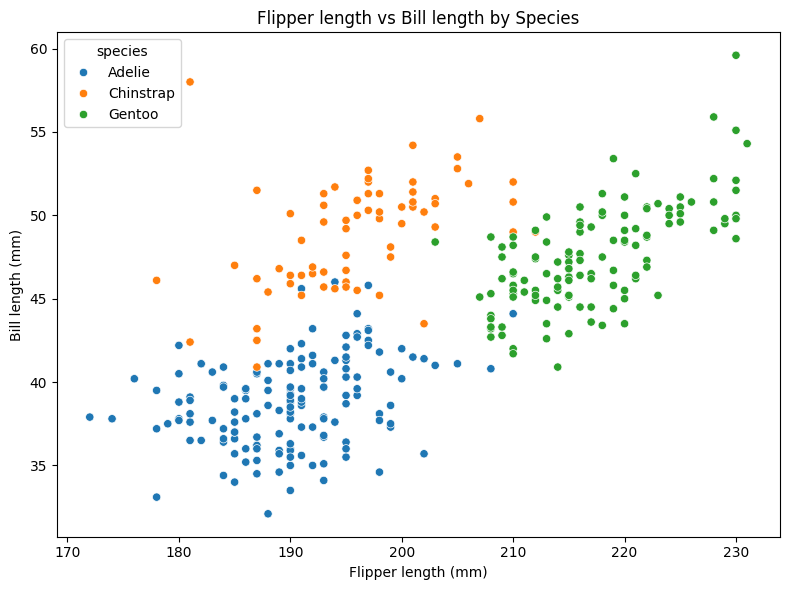

Saved chart to: artifacts\flipper_vs_bill_length_by_species.png


In [12]:
# Original Scatter Plot and Save Artifact

LOG.info("Creating scatter plot: flipper length vs bill length")

plt.figure(figsize=(8, 6))

scatter_plt: Axes = sns.scatterplot(
    data=df_features,
    x="flipper_length_mm",
    y="bill_length_mm",
    hue=GROUP_COL,
)

scatter_plt.set_xlabel("Flipper length (mm)")
scatter_plt.set_ylabel("Bill length (mm)")
scatter_plt.set_title("Flipper length vs Bill length by Species")

plt.tight_layout()

scatter_path = ARTIFACTS_DIR / "flipper_vs_bill_length_by_species.png"
plt.savefig(scatter_path)

plt.show()

print(f"Saved chart to: {scatter_path}")

2026-05-24 14:45:38 | INFO | EDA | Creating box plot: flipper length by species


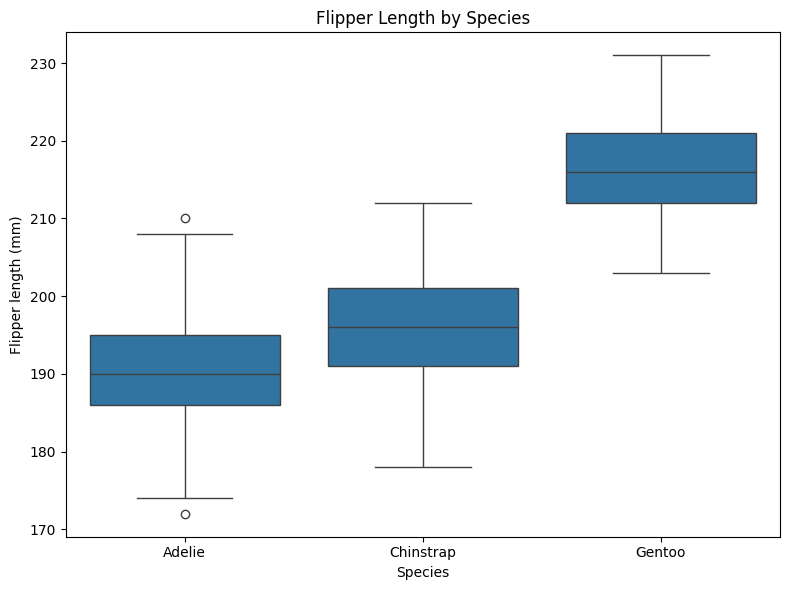

Saved chart to: artifacts\flipper_length_by_species.png


In [13]:
# Original Box Plot and Save Artifact

LOG.info("Creating box plot: flipper length by species")

plt.figure(figsize=(8, 6))

box_plt: Axes = sns.boxplot(
    data=df_features,
    x=GROUP_COL,
    y="flipper_length_mm",
)

box_plt.set_xlabel("Species")
box_plt.set_ylabel("Flipper length (mm)")
box_plt.set_title("Flipper Length by Species")

plt.tight_layout()

box_path = ARTIFACTS_DIR / "flipper_length_by_species.png"
plt.savefig(box_path)

plt.show()

print(f"Saved chart to: {box_path}")

2026-05-24 14:45:38 | INFO | EDA | Creating bar chart: average body mass by species


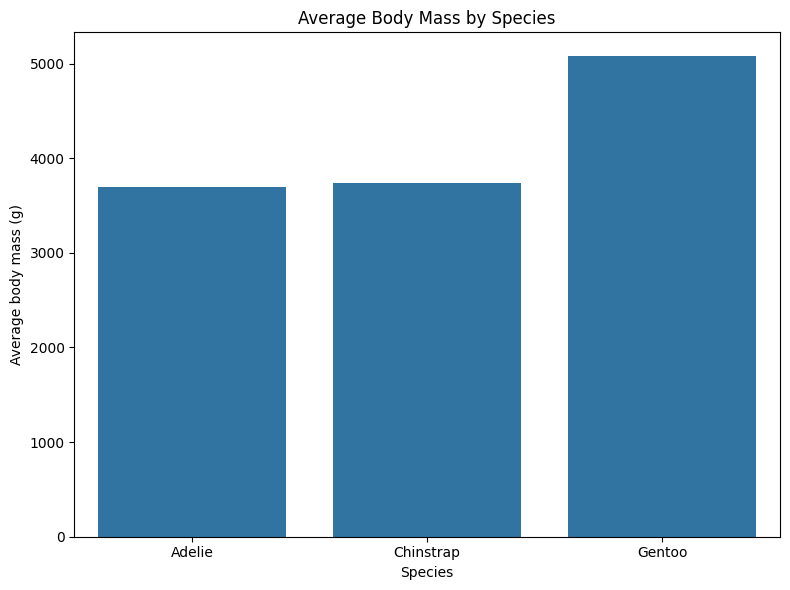

Saved chart to: artifacts\average_body_mass_by_species.png


In [14]:
# New Problem Chart by Species

LOG.info("Creating bar chart: average body mass by species")

plt.figure(figsize=(8, 6))

species_bar: Axes = sns.barplot(
    data=species_size_summary,
    x="species",
    y="avg_body_mass_g",
)

species_bar.set_xlabel("Species")
species_bar.set_ylabel("Average body mass (g)")
species_bar.set_title("Average Body Mass by Species")

plt.tight_layout()

species_body_mass_path = ARTIFACTS_DIR / "average_body_mass_by_species.png"
plt.savefig(species_body_mass_path)

plt.show()

print(f"Saved chart to: {species_body_mass_path}")

2026-05-24 14:45:38 | INFO | EDA | Creating bar chart: average body mass by island


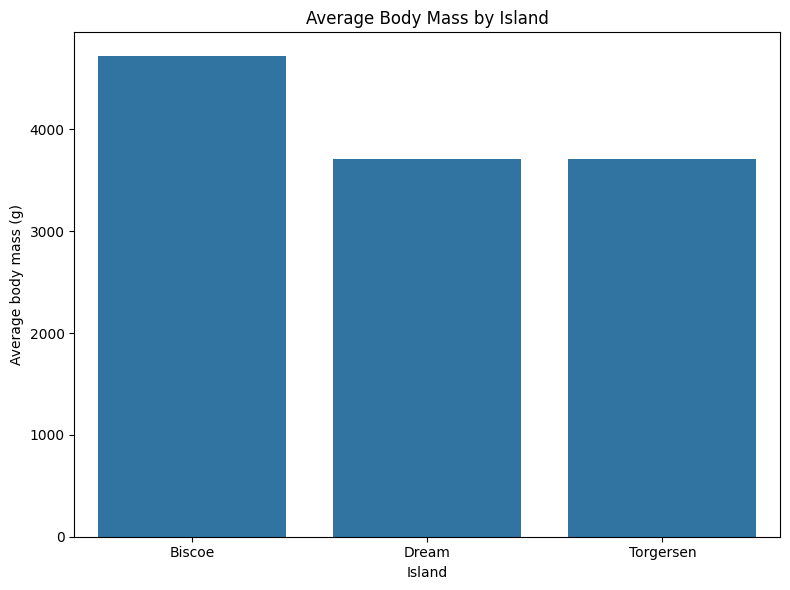

Saved chart to: artifacts\average_body_mass_by_island.png


In [15]:
# New Problem Chart by Island

LOG.info("Creating bar chart: average body mass by island")

plt.figure(figsize=(8, 6))

island_bar: Axes = sns.barplot(
    data=island_size_summary,
    x="island",
    y="avg_body_mass_g",
)

island_bar.set_xlabel("Island")
island_bar.set_ylabel("Average body mass (g)")
island_bar.set_title("Average Body Mass by Island")

plt.tight_layout()

island_body_mass_path = ARTIFACTS_DIR / "average_body_mass_by_island.png"
plt.savefig(island_body_mass_path)

plt.show()

print(f"Saved chart to: {island_body_mass_path}")

In [16]:
# Save Summary Tables

species_summary_path = ARTIFACTS_DIR / "species_size_summary.csv"
island_summary_path = ARTIFACTS_DIR / "island_size_summary.csv"

species_size_summary.to_csv(species_summary_path, index=False)
island_size_summary.to_csv(island_summary_path, index=False)

print(f"Saved species summary to: {species_summary_path}")
print(f"Saved island summary to: {island_summary_path}")

Saved species summary to: artifacts\species_size_summary.csv
Saved island summary to: artifacts\island_size_summary.csv


## Final Reflection

This notebook completed the original EDA workflow and added a technical modification.

The technical modification created new engineered fields, including body mass in kilograms, flipper-to-body ratio, and size category. These fields made the dataset more useful for analysis.

The new problem applied the same EDA skills to a wildlife research question. By comparing average body mass by species and island, the notebook shows how analysts can use Python, Pandas, Seaborn, and Matplotlib to turn raw data into useful insights.

The notebook also saved charts and summary CSV files into the `artifacts/` folder so they can be shared in GitHub or used in a README file.